# 270. Closest Binary Search Tree Value
https://leetcode.com/problems/closest-binary-search-tree-value/

## Complexity Comparison

| Approach | Time | Space | Description |
|----------|------|-------|-------------|
| Inorder traversal | O(n) | O(n) | Collect all values, find closest |
| **BST search (Optimal)** | **O(h)** | **O(1)** | Binary search tracking closest |

## Methodology

Traverse the BST like a binary search. At each node, update the closest value if the current node is closer to the target. Move left if target < node value, right otherwise. This runs in O(h) time where h is the tree height.

## Solutions

### C#

In [ ]:
public class Solution {
    public int ClosestValue(TreeNode root, double target) {
        int closest = root.val;
        while (root != null) {
            if (Math.Abs(root.val - target) < Math.Abs(closest - target)) {
                closest = root.val;
            }
            root = target < root.val ? root.left : root.right;
        }
        return closest;
    }
}

### Python

In [ ]:
class Solution:
    def closestValue(self, root: Optional[TreeNode], target: float) -> int:
        closest = root.val
        while root:
            if abs(root.val - target) < abs(closest - target):
                closest = root.val
            root = root.left if target < root.val else root.right
        return closest

### Go

In [ ]:
func closestValue(root *TreeNode, target float64) int {
    closest := root.Val
    for root != nil {
        if math.Abs(float64(root.Val)-target) < math.Abs(float64(closest)-target) {
            closest = root.Val
        }
        if target < float64(root.Val) {
            root = root.Left
        } else {
            root = root.Right
        }
    }
    return closest
}

### Rust

In [ ]:
use std::rc::Rc;
use std::cell::RefCell;

impl Solution {
    pub fn closest_value(root: Option<Rc<RefCell<TreeNode>>>, target: f64) -> i32 {
        let mut closest = root.as_ref().unwrap().borrow().val;
        let mut node = root;
        while let Some(n) = node {
            let val = n.borrow().val;
            if (val as f64 - target).abs() < (closest as f64 - target).abs() {
                closest = val;
            }
            node = if target < val as f64 {
                n.borrow().left.clone()
            } else {
                n.borrow().right.clone()
            };
        }
        closest
    }
}

## Example Scenarios

1. **Common Case**  
   **Input:** `root = [4,2,5,1,3], target = 3.7`  
   Traverse: $|4 - 3.7| = 0.3$, $|3 - 3.7| = 0.7$, so 4 is closer. Returns `4`.

2. **Slightly Complex**  
   **Input:** `root = [10,5,15,3,7,13,18,1,4,6,8], target = 6.5`  
   BST search: $10 \to 5 \to 7 \to 6$. Distances: $|7 - 6.5| = 0.5$, $|6 - 6.5| = 0.5$. Tie goes to smaller value. Returns `6`.

3. **Edge Case: Time Factor**  
   **Input:** Skewed BST with $10^4$ nodes (1,2,3,...,10000), `target = 10001`.  
   Traverses all $O(n)$ nodes down the right spine. Closest is $10000$.

4. **Edge Case: Space Factor**  
   **Input:** `root = [1], target = 100.0`  
   Single node, $O(1)$ space. Returns `1` regardless of target distance.

5. **Almost-Impossible but Plausible**  
   **Input:** Balanced BST of $10^4$ nodes, `target = 0.0` (smaller than all values).  
   Always goes left at each level. Traverses $O(\log n) \approx 14$ nodes. Returns the leftmost (smallest) value.

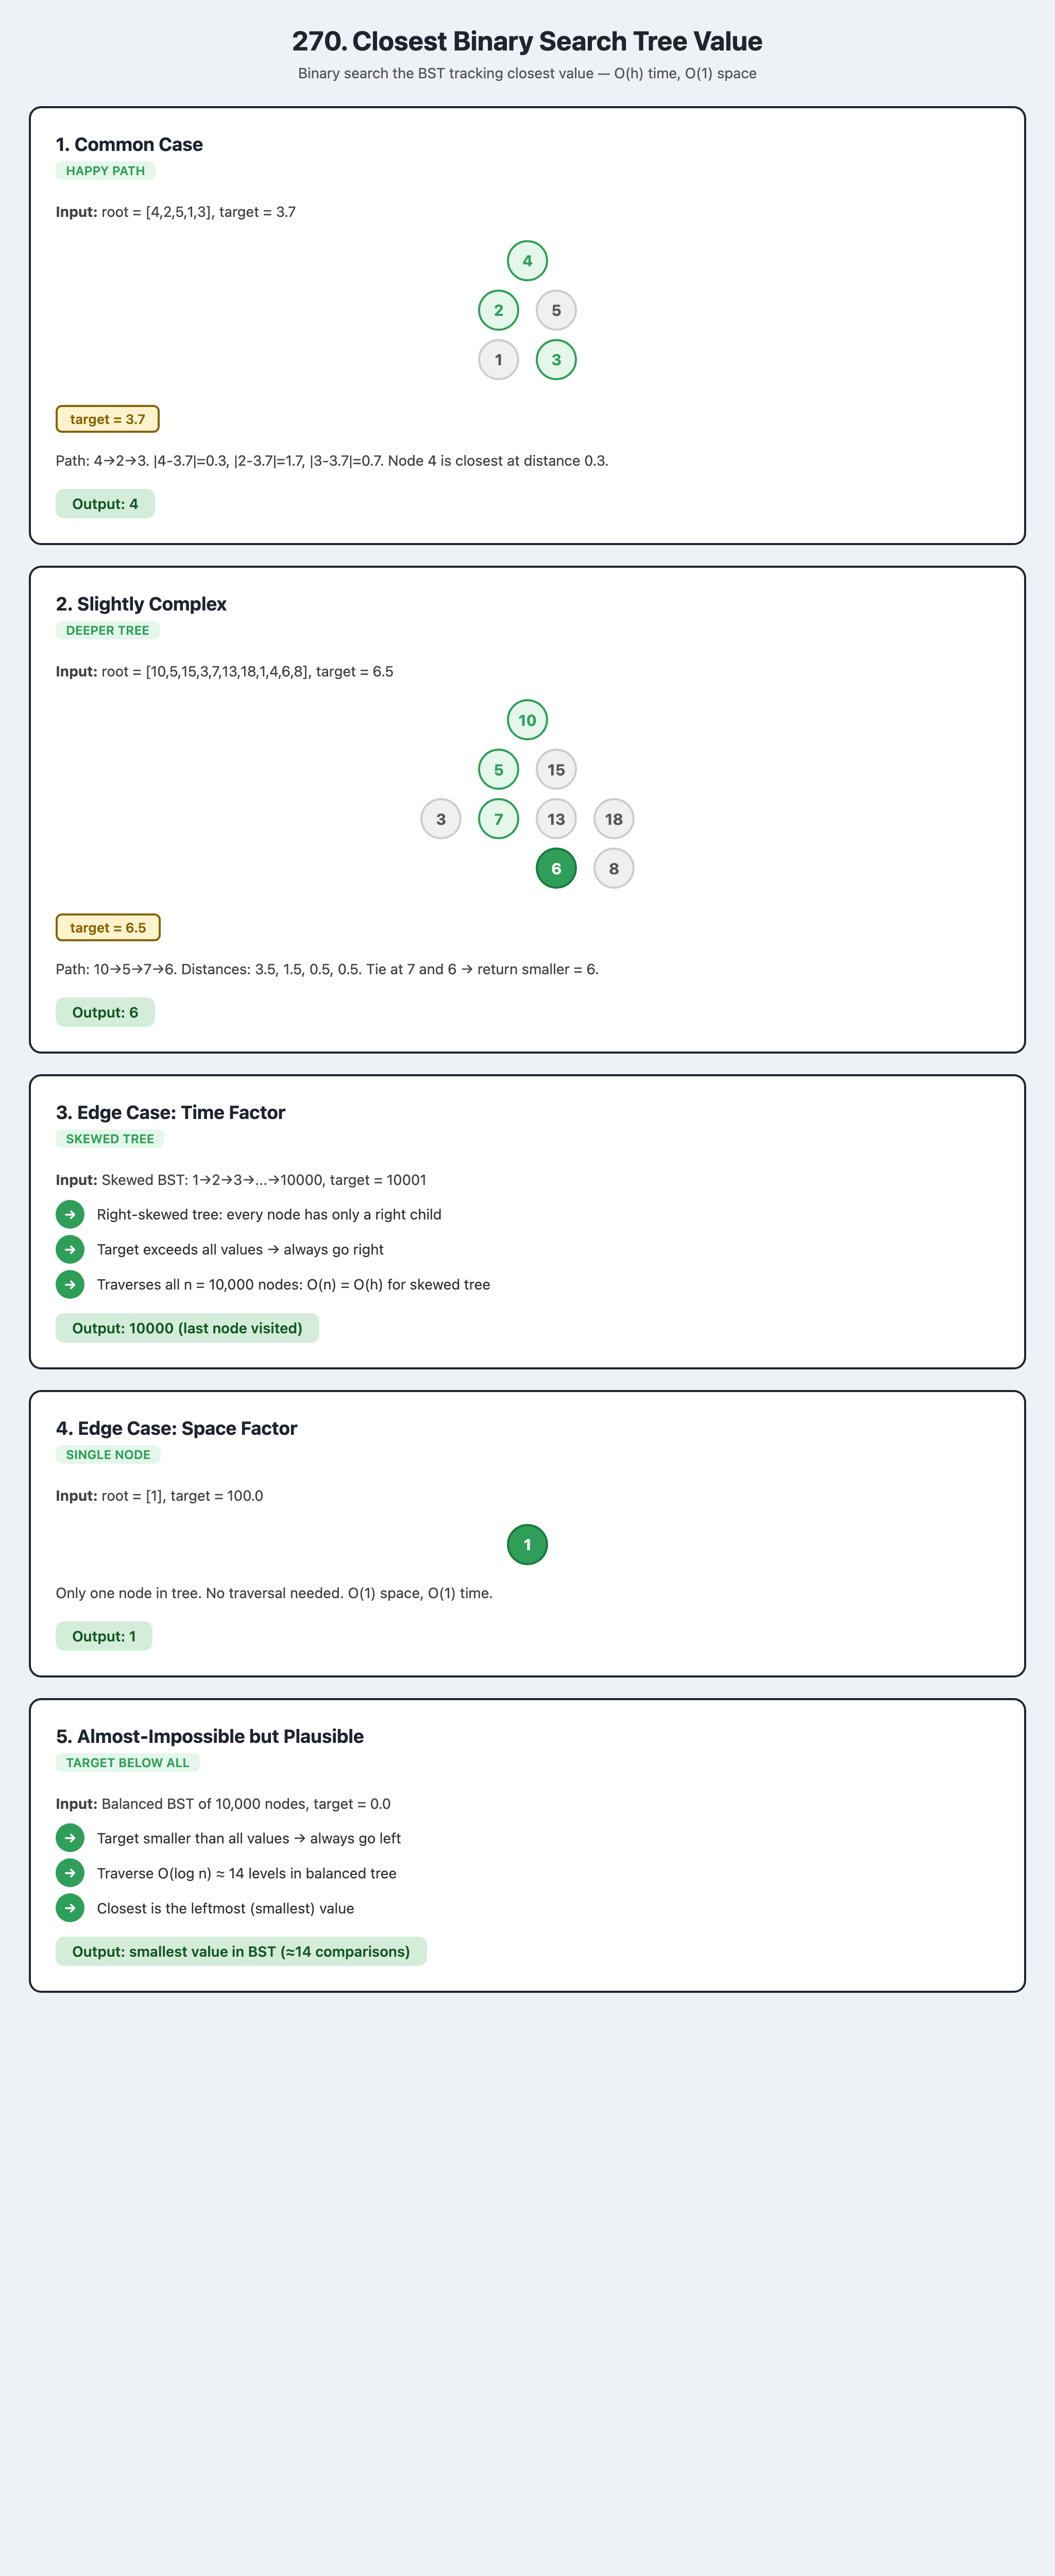